### Problem Statement:
- Predict Minimum and maximum temperatures during a day based on various features.
  
### target variables here:

1) Next_Tmax: Next day maximum temperature

2) Next_Tmin: Next day minimum temperature 


## Import Data

In [173]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv('/kaggle/input/datasets/smokingkrils/temperature-forecast-project-using-ml/temp.csv')

# Display First 5 Rows
df.head()

,station,Date,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
0,1.0,30-06-2013,28.7,21.4,58.255688,91.116364,28.074101,23.006936,6.818887,69.451805,...,0.0,0.0,0.0,37.6046,126.991,212.3350,2.7850,5992.895996,29.1,21.2
1,2.0,30-06-2013,31.9,21.6,52.263397,90.604721,29.850689,24.035009,5.691890,51.937448,...,0.0,0.0,0.0,37.6046,127.032,44.7624,0.5141,5869.312500,30.5,22.5
2,3.0,30-06-2013,31.6,23.3,48.690479,83.973587,30.091292,24.565633,6.138224,20.573050,...,0.0,0.0,0.0,37.5776,127.058,33.3068,0.2661,5863.555664,31.1,23.9
3,4.0,30-06-2013,32.0,23.4,58.239788,96.483688,29.704629,23.326177,5.650050,65.727144,...,0.0,0.0,0.0,37.6450,127.022,45.7160,2.5348,5856.964844,31.7,24.3
4,5.0,30-06-2013,31.4,21.9,56.174095,90.155128,29.113934,23.486480,5.735004,107.965535,...,0.0,0.0,0.0,37.5507,127.135,35.0380,0.5055,5859.552246,31.2,22.5


## EDA

In [174]:
# Size of Dataset
df.shape

(7752, 25)

In [175]:
# Some basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7752 entries, 0 to 7751
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   station           7750 non-null   float64
 1   Date              7750 non-null   object 
 2   Present_Tmax      7682 non-null   float64
 3   Present_Tmin      7682 non-null   float64
 4   LDAPS_RHmin       7677 non-null   float64
 5   LDAPS_RHmax       7677 non-null   float64
 6   LDAPS_Tmax_lapse  7677 non-null   float64
 7   LDAPS_Tmin_lapse  7677 non-null   float64
 8   LDAPS_WS          7677 non-null   float64
 9   LDAPS_LH          7677 non-null   float64
 10  LDAPS_CC1         7677 non-null   float64
 11  LDAPS_CC2         7677 non-null   float64
 12  LDAPS_CC3         7677 non-null   float64
 13  LDAPS_CC4         7677 non-null   float64
 14  LDAPS_PPT1        7677 non-null   float64
 15  LDAPS_PPT2        7677 non-null   float64
 16  LDAPS_PPT3        7677 non-null   float64


In [176]:
# Identifying null values
df.isnull().sum()

station              2
Date                 2
Present_Tmax        70
Present_Tmin        70
LDAPS_RHmin         75
LDAPS_RHmax         75
LDAPS_Tmax_lapse    75
LDAPS_Tmin_lapse    75
LDAPS_WS            75
LDAPS_LH            75
LDAPS_CC1           75
LDAPS_CC2           75
LDAPS_CC3           75
LDAPS_CC4           75
LDAPS_PPT1          75
LDAPS_PPT2          75
LDAPS_PPT3          75
LDAPS_PPT4          75
lat                  0
lon                  0
DEM                  0
Slope                0
Solar radiation      0
Next_Tmax           27
Next_Tmin           27
dtype: int64

In [177]:
# Convert to Datetime
df['Date'] = pd.to_datetime(df['Date'])

#fill NA
df = df.fillna(df.median(numeric_only=True))
df['Date'] = df['Date'].ffill()

# Break down the Date column
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfYear"] = df["Date"].dt.dayofyear

# Drop Date column
df.drop('Date', axis= 1, inplace= True )

In [178]:
df['station'].value_counts()

station
13.0    312
2.0     310
3.0     310
4.0     310
5.0     310
6.0     310
7.0     310
8.0     310
1.0     310
9.0     310
10.0    310
11.0    310
12.0    310
14.0    310
15.0    310
16.0    310
17.0    310
18.0    310
19.0    310
20.0    310
21.0    310
22.0    310
23.0    310
24.0    310
25.0    310
Name: count, dtype: int64

In [179]:
df.columns

Index(['station', 'Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin', 'LDAPS_RHmax',
       'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS', 'LDAPS_LH',
       'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4', 'LDAPS_PPT1',
       'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon', 'DEM', 'Slope',
       'Solar radiation', 'Next_Tmax', 'Next_Tmin', 'year', 'month', 'Day',
       'DayOfYear'],
      dtype='object')

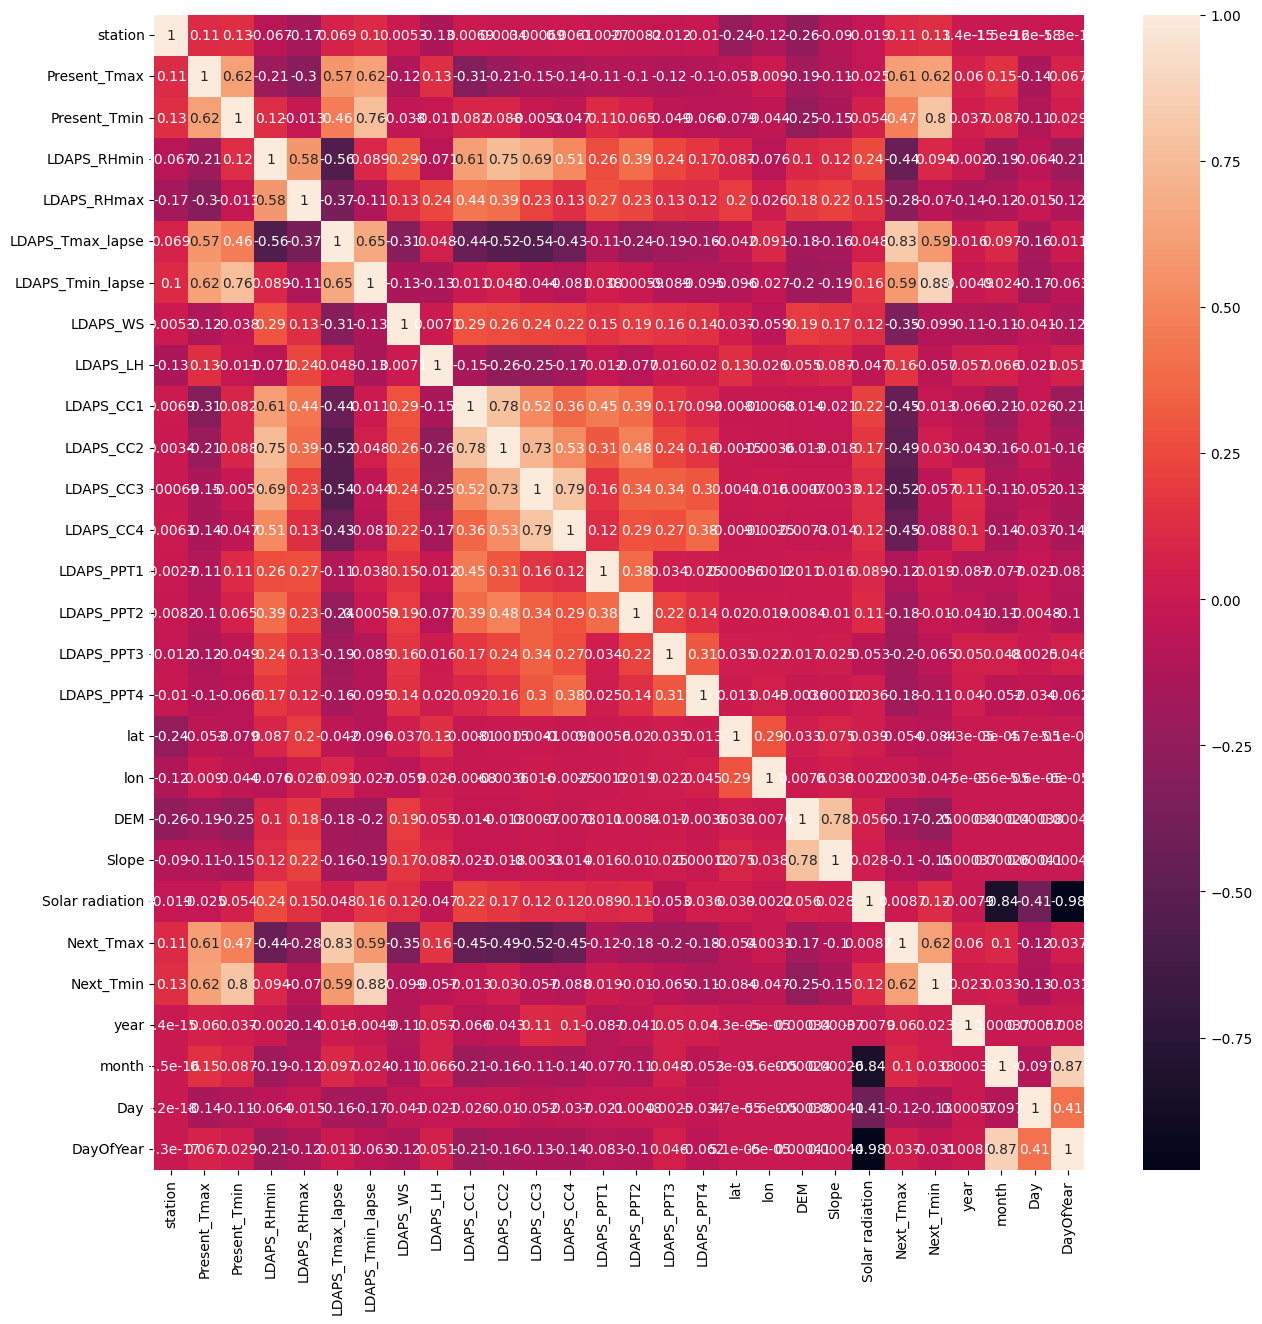

In [180]:
plt.figure(figsize = (15,15))
sns.heatmap(df.corr(numeric_only = True), annot= True)
plt.show()

<Axes: xlabel='Next_Tmax', ylabel='LDAPS_CC1'>

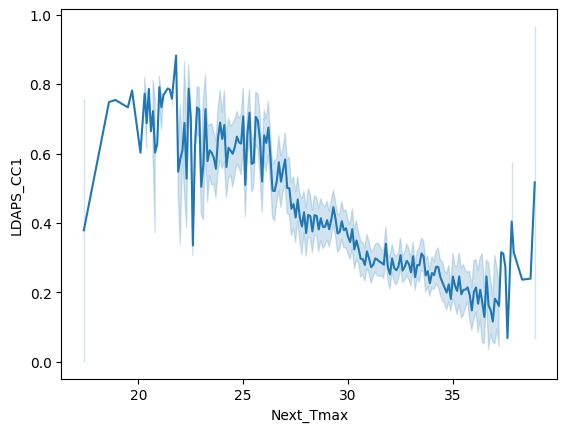

In [181]:
sns.lineplot(df,x ='Next_Tmax', y= 'LDAPS_CC1' )

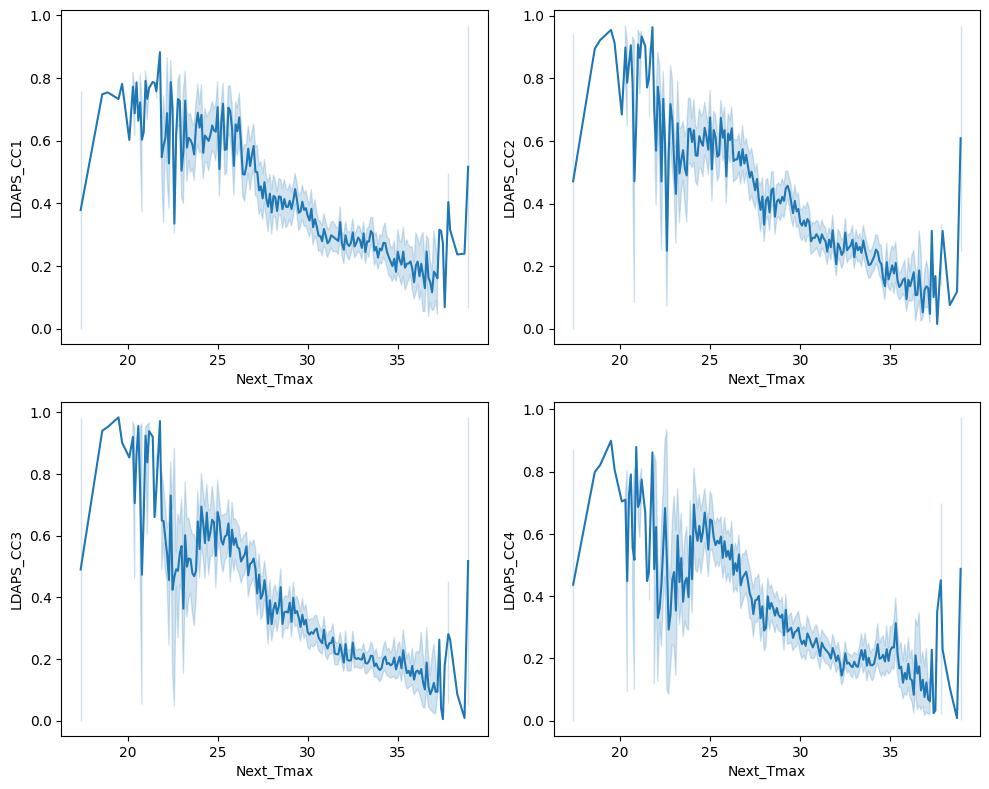

In [182]:
plt.figure(figsize=(10, 8))

def plotting(col, n):
    plt.subplot(2, 2, n)
    sns.lineplot(data=df, x='Next_Tmax', y=col)

plotting('LDAPS_CC1', 1)
plotting('LDAPS_CC2', 2)
plotting('LDAPS_CC3', 3)
plotting('LDAPS_CC4', 4)

plt.tight_layout()
plt.show()

## MODELING

In [183]:
# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor

# Models that can predict multiple variables
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [184]:
# splitting the target and dependencies
x = df.drop(columns = ['Next_Tmax', 'Next_Tmin'])
y = df[['Next_Tmax', 'Next_Tmin']]

# Convert station to Category and encode it. 
x['station'] = x['station'].astype('category')
x = pd.get_dummies(x, columns=['station'], drop_first=False)

# Split Train and Test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scaling the Data. 
scaler= StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [185]:
# Testing Models

models = {
    "Linear Regression": LinearRegression(), 
    "KNN": KNeighborsRegressor(), 
    "Decision Tree": DecisionTreeRegressor(), 
    "Random Forest": RandomForestRegressor()
}

result = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    MAE = mean_absolute_error(y_test, y_pred)
    MSE = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    

    result.append({
        "Model": name, 
        "Mean Absolute Error": round(MAE, 2), 
        "Mean Squared Error": round(MSE, 2), 
        "R2 Score": round(r2, 2)
         
    })
result

[{'Model': 'Linear Regression',
  'Mean Absolute Error': 0.87,
  'Mean Squared Error': 1.41,
  'R2 Score': 0.83},
 {'Model': 'KNN',
  'Mean Absolute Error': 1.21,
  'Mean Squared Error': 2.54,
  'R2 Score': 0.69},
 {'Model': 'Decision Tree',
  'Mean Absolute Error': 1.04,
  'Mean Squared Error': 2.07,
  'R2 Score': 0.74},
 {'Model': 'Random Forest',
  'Mean Absolute Error': 0.67,
  'Mean Squared Error': 0.78,
  'R2 Score': 0.9}]

In [186]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        x,
        y,
        cv=5,
        scoring='neg_mean_absolute_error'
    )

    print(f"{name}")
    print(f"Fold MAE : {-scores}")
    print(f"Mean MAE : {-scores.mean():.4f}")
    print(f"Std Dev  : {scores.std():.4f}")
    print("-" * 40)

Linear Regression
Fold MAE : [0.98799867 1.05434108 0.89824339 0.98073113 1.11186984]
Mean MAE : 1.0066
Std Dev  : 0.0723
----------------------------------------
Decision Tree
Fold MAE : [1.61950355 1.51344294 1.4846129  1.5083871  1.62693548]
Mean MAE : 1.5506
Std Dev  : 0.0602
----------------------------------------
Random Forest
Fold MAE : [1.06013121 1.12476306 1.06970452 1.13685581 1.10169548]
Mean MAE : 1.0986
Std Dev  : 0.0299
----------------------------------------
KNN
Fold MAE : [1.5611283  2.21831077 1.90733548 2.2928     2.02571613]
Mean MAE : 2.0011
Std Dev  : 0.2589
----------------------------------------


The Random Forest Model performs the best, so we are going to use it.  

In [187]:
rf = RandomForestRegressor(random_state=42)

# Hyperparameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

# Train Grid Search
grid_search.fit(x_train, y_train)

# Best Parameters
print("="*50)
print("Best Parameters:")
print(grid_search.best_params_)

# Best Cross Validation MAE
print("\nBest Cross Validation MAE:")
print(-grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation MAE:
0.6884503952977565


In [192]:
model_final = RandomForestRegressor(random_state=42, n_estimators= 200 )

model_final.fit(x_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [193]:
y_pred = model_final.predict(x_test)

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(MAE, 2))
print("Mean Squared Error:", round(MSE, 2))
print("R2 Score:", round(r2, 2))

Mean Absolute Error: 0.67
Mean Squared Error: 0.79
R2 Score: 0.9
